In [1]:
from pathlib import Path

import torch
import torchaudio
from IPython.display import Audio
import dac
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
import pickle

from sklearn.decomposition import PCA

In [2]:
#@title Download and load DAC model

model_path = dac.utils.download()
model = dac.DAC.load(model_path)
model = model.to('cpu')

/home/mille/miniconda3/envs/dac/lib/python3.13/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


In [3]:
output_dir = "output"

In [4]:
target_dir = "training_data/beatbox"
corpus_dir = "training_data/drum_kit"

In [5]:
# Load the audio file

def load_mono(file_name, target_sr):
    audio, sr = torchaudio.load(file_name)

    # collapse to mono
    if audio.shape[0] > 1:
        audio = audio.mean(0, keepdim=True)

    if sr != target_sr:
        audio = torchaudio.functional.resample(audio, sr, target_sr)
        sr = target_sr
    audio = audio.clamp(-1, 1) # clip at 0dB
    return audio

def trim_silence(input, sample_rate):
    # Compute root mean square (RMS) energy per frame
    frame_size = int(sample_rate * 0.05)
    rms_energy = input.unfold(1, frame_size, frame_size).pow(2).mean(dim=2).sqrt()

    # Set silence threshold (e.g., 10% of max RMS energy)
    threshold = 0.1 * rms_energy.max()

    # Find frames where energy is above the threshold
    non_silent_indices = (rms_energy > threshold).nonzero(as_tuple=True)[1]

    trimmed_waveform = torch.zeros([1,1])
    for index in non_silent_indices:
        trimmed_waveform = torch.cat([trimmed_waveform, input[:,index*frame_size:(index+1)*frame_size]], dim=1)
    
    return trimmed_waveform

In [6]:
target_sr = model.sample_rate

target_files = os.listdir(target_dir)
corpus_files = os.listdir(corpus_dir)

target_waveforms = [trim_silence(load_mono((target_dir + "/" + file), target_sr), target_sr) for file in target_files if file[-4:] == ".wav"]
corpus_waveforms = [trim_silence(load_mono((corpus_dir + "/" + file), target_sr), target_sr) for file in corpus_files if file[-4:] == ".wav"]

In [ ]:
with torch.inference_mode():
    target_embeddings = [model.encode(model.preprocess(wave, target_sr).to(model.device).unsqueeze(0))[0] for wave in target_waveforms]
    target_concat = torch.cat(target_embeddings, dim=2)

    corpus_embeddings = [model.encode(model.preprocess(wave, target_sr).to(model.device).unsqueeze(0))[0] for wave in corpus_waveforms]
    corpus_concat = torch.cat(corpus_embeddings, dim=2)


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fafbc499010>>
Traceback (most recent call last):
  File "/home/mille/miniconda3/envs/dac/lib/python3.13/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
var_target, mean_target = torch.var_mean(target_concat, dim=2)
var_corpus, mean_corpus = torch.var_mean(corpus_concat, dim=2)

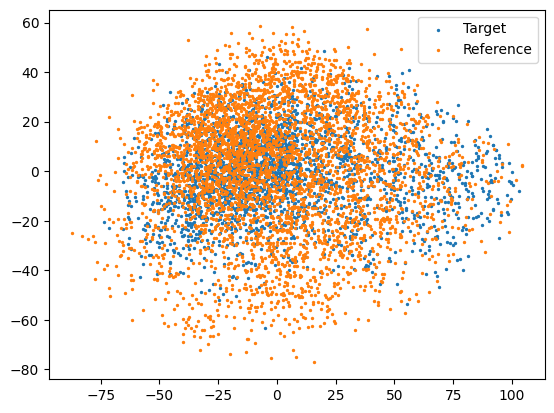

In [ ]:
total_concat = torch.cat((target_embeddings + corpus_embeddings), dim=2)
total_concat = np.transpose(total_concat.detach().cpu().numpy()[0,:,:])

pca = PCA(n_components=2)

pca.fit(total_concat)

pcat_target = pca.transform(np.transpose(target_concat.detach().cpu().numpy()[0,:,:]))
pcat_corpus = pca.transform(np.transpose(corpus_concat.detach().cpu().numpy()[0,:,:]))

plt.scatter(pcat_target[:,0], pcat_target[:,1], s=2, label="Target")
plt.scatter(pcat_corpus[:,0], pcat_corpus[:,1], s=2, label="Reference")
plt.legend()

In [ ]:
var_target = var_target.reshape((1, 1024, 1))
mean_target = mean_target.reshape((1, 1024, 1))
var_corpus = var_corpus.reshape((1, 1024, 1))
mean_corpus = mean_corpus.reshape((1, 1024, 1))

In [ ]:
with open("lin_model.pickle", 'wb') as f:
    pickle.dump((var_target, mean_target, var_corpus, mean_corpus), f)

In [7]:
with open("lin_model.pickle", 'rb') as f:
    var_target, mean_target, var_corpus, mean_corpus = pickle.load(f)

distributions will "intersect" if

$\mu \leq 2\sigma$

or

$\theta \leq \cos^{-1} \left( 1 - \frac{\mu^2}{2\sigma^2} \right)$

meaning they will be hard to separate and transfer between (i think, idk)

In [ ]:
print(torch.mean(var_target), torch.linalg.vector_norm(mean_target))
print(torch.mean(var_corpus), torch.linalg.vector_norm(mean_corpus))
cosim = torch.nn.CosineSimilarity()
print(cosim(mean_target, mean_corpus))

# the distributions are further away from the origin than they are "wide". they are also around 40 degrees away from each other.
# the distributions do not intersect, therefore a transformation from one of them to the other is meaningful with regards to
# imposing the characterstics of a sound from one distribution onto the other

tensor(11.9767) tensor(32.7923)
tensor(11.9359) tensor(32.2559)
tensor([[0.7542]])


$\sigma^2_d = \sigma^2_x + (\sigma^2_y - \sigma^2_x)\,\alpha$

$\mu_d = \mu_x + (\mu_y - \mu_x)\,\beta$

In [8]:
alpha = 3; beta = 3

var_desired = var_target + (var_corpus - var_target) * alpha

mean_desired = mean_target + (mean_corpus - mean_target) * beta

$z_{\hat{y}} = G(z_x) = \mu_d + \frac{\sigma_d}{\sigma_x}\,(z_x - \mu_x)$

In [9]:
def lin_transfer(input, var_target, mean_target, var_desired, mean_desired):
    output = mean_desired + (torch.pow(var_desired, 0.5)/torch.pow(var_target, 0.5)) * (input - mean_target)
    return output

In [10]:
# inference
test_file = "training_data/beatbox/6.wav"
test_audio = load_mono(test_file, target_sr)
with torch.inference_mode():
    z_test = model.encode(model.preprocess(test_audio, target_sr).to(model.device).unsqueeze(0))[0]
    z_transformed = model.quantizer(lin_transfer(z_test, var_target, mean_target, var_desired, mean_desired), None)[0]
    output_audio_dry = model.decode(z_test)
    output_audio_transformed = model.decode(z_transformed)



KeyboardInterrupt



In [23]:
display(Audio(output_audio_dry[0].detach().cpu().numpy(), rate=target_sr))
display(Audio(output_audio_transformed[0].detach().cpu().numpy(), rate=target_sr))

In [21]:
with torch.inference_mode():
    bullshit = model.decode(target_concat[:,:,:500])

display(Audio(bullshit[0].detach().cpu().numpy(), rate=target_sr))

In [ ]:
torchaudio.save("beatbox_dump.flac", bullshit[0], target_sr)